<a href="https://colab.research.google.com/github/tettty1981-lang/data-analytics-course/blob/main/HW_11_1_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('/content/yulu_rental.csv')

In [2]:
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [3]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [4]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [5]:
df.shape

(10886, 19)

In [6]:
df.index[:5]

DatetimeIndex(['2011-01-01 00:00:00', '2011-01-01 01:00:00',
               '2011-01-01 02:00:00', '2011-01-01 03:00:00',
               '2011-01-01 04:00:00'],
              dtype='datetime64[ns]', name='datetime', freq=None)

**Обсяг даних:** 10886 рядків, 19 колонок

**Рівень деталізації:** погодинний — кожен рядок містить дані оренд за одну конкретну годину

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.



In [7]:
daily_count = df.groupby('date')['count'].sum()

In [8]:
daily_count

,count
date,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600
...,...
2012-12-15,5047
2012-12-16,3786
2012-12-17,4585


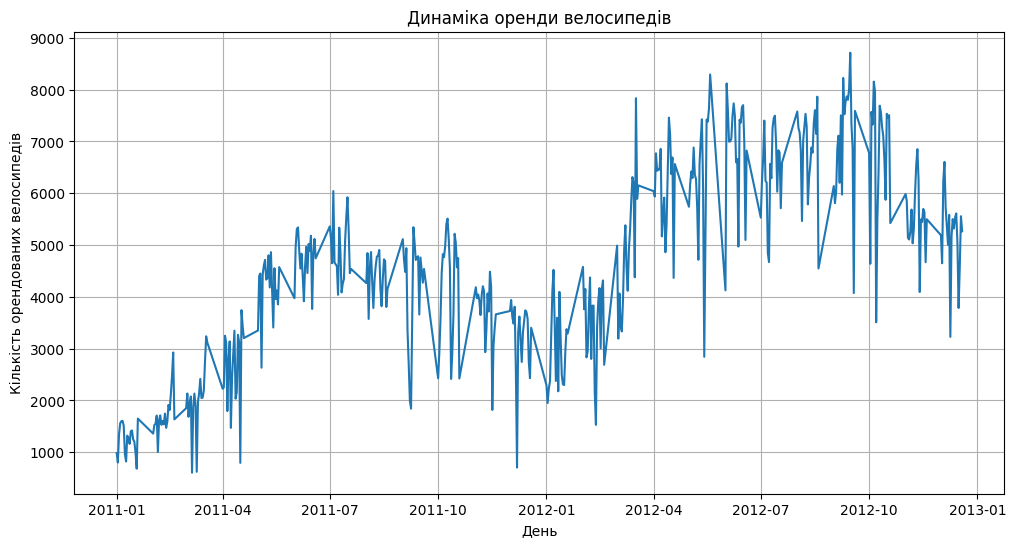

In [9]:
daily_count.plot(
    kind='line',
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    xlabel='День',
    ylabel='Кількість орендованих велосипедів',
    grid=True # лінії вертикальні розподілу
);

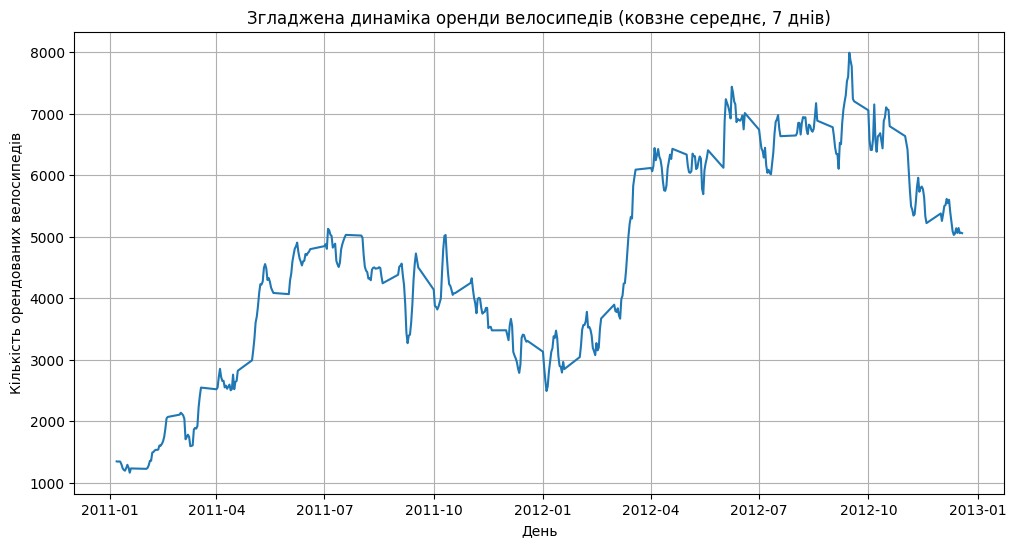

In [10]:

daily_count.rolling(window=7).mean().plot(
    kind='line',
    figsize=(12, 6),
    title='Згладжена динаміка оренди велосипедів (ковзне середнє, 7 днів)',
    xlabel='День',
    ylabel='Кількість орендованих велосипедів',
    grid=True # лінії вертикальні розподілу
);



In [11]:
monthly_avg = df[['count', 'temp']].resample('ME').mean()

In [12]:
monthly_avg

,count,temp
datetime,,
2011-01-31,54.645012,8.633782
2011-02-28,73.641256,11.331076
2011-03-31,86.849776,14.063184
2011-04-30,111.026374,17.776879
2011-05-31,174.809211,21.528596
2011-06-30,196.877193,28.191096
2011-07-31,203.614035,29.967763
2011-08-31,182.666667,29.667456
2011-09-30,174.622517,25.141236


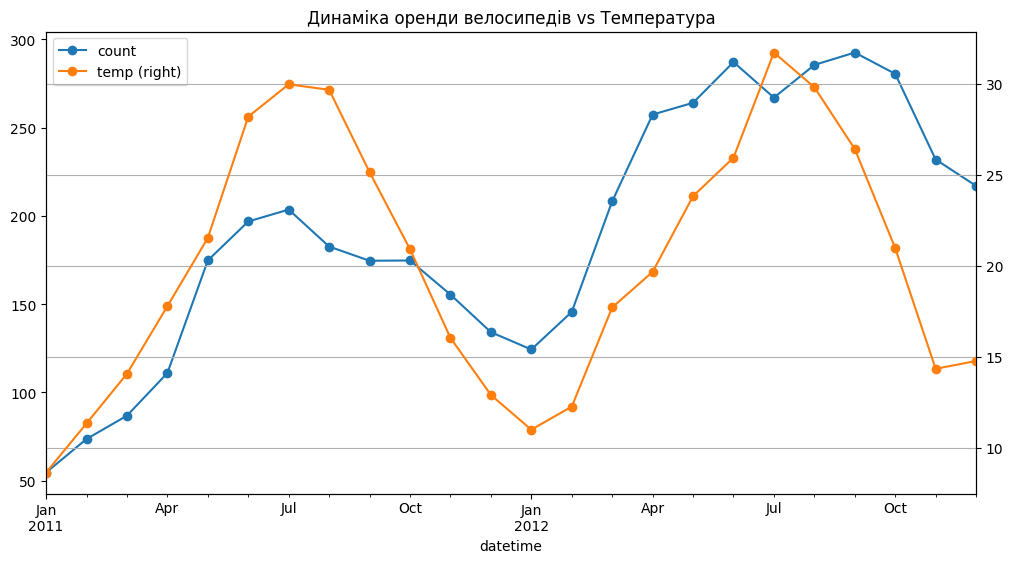

In [13]:
monthly_avg.plot(
    kind='line',
    figsize=(12, 6),
    marker='o',
    secondary_y='temp',
    title='Динаміка оренди велосипедів vs Температура',
    grid=True # лінії вертикальні розподілу
);

In [14]:
# Для мінімальних значень
dates_min = pd.to_datetime(['2011-03-06', '2011-03-10', '2011-01-18', '2011-12-07',
                              '2011-04-16', '2011-01-02', '2011-01-09', '2011-01-08',
                              '2011-01-01', '2011-01-17']).date

df[df['date'].isin(dates_min)][['date', 'holiday', 'workingday', 'weather']].drop_duplicates()

,date,holiday,workingday,weather
datetime,,,,
2011-01-01 00:00:00,2011-01-01,0,0,1
2011-01-01 05:00:00,2011-01-01,0,0,2
2011-01-01 18:00:00,2011-01-01,0,0,3
2011-01-02 00:00:00,2011-01-02,0,0,2
2011-01-02 06:00:00,2011-01-02,0,0,3
2011-01-02 17:00:00,2011-01-02,0,0,1
2011-01-08 00:00:00,2011-01-08,0,0,2
2011-01-08 03:00:00,2011-01-08,0,0,3
2011-01-08 13:00:00,2011-01-08,0,0,1


In [15]:
# Для максимальних значень
dates_max = pd.to_datetime(['2012-09-15', '2012-05-19', '2012-09-09', '2012-10-05',
                              '2012-06-02', '2012-09-14', '2012-10-06', '2012-09-12',
                              '2012-08-18', '2012-03-17']).date

df[df['date'].isin(dates_max)][['date', 'holiday', 'workingday', 'weather']].drop_duplicates()

,date,holiday,workingday,weather
datetime,,,,
2012-03-17 00:00:00,2012-03-17,0,0,2
2012-03-17 12:00:00,2012-03-17,0,0,1
2012-05-19 00:00:00,2012-05-19,0,0,1
2012-06-02 00:00:00,2012-06-02,0,0,2
2012-06-02 03:00:00,2012-06-02,0,0,1
2012-08-18 00:00:00,2012-08-18,0,0,2
2012-08-18 01:00:00,2012-08-18,0,0,3
2012-08-18 03:00:00,2012-08-18,0,0,1
2012-09-09 00:00:00,2012-09-09,0,0,2


**Питання для інтерпретації:**

**1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?**

Кожна точка — це один день. А сусідні дні можуть дуже сильно відрізнятись за кількістю оренд через:

Погоду — дощовий/холодний день різко знижує оренди порівняно із

*   Погоду — дощовий/холодний день різко знижує оренди порівняно із
сусідніми сонячними днями
*   Тип дня — будній день і вихідний мають різний патерн попиту (люди їздять на роботу/на відпочинок)
  
Оскільки ці фактори змінюються різко від дня до дня (а не поступово), лінія графіка "стрибає" — звідси й заломи.

Їх можна згладити через `rolling(window=7)`, як видно на другому графіку.
Це означає: "візьми вікно шириною 7 днів і посувай його по одному дню за раз". Для кожної позиції вікна рахуємо середнє значення всередині нього.

**2. Які загальні тенденції ви бачите на графіку?**

Побудувала графік відносно середньої кількісті оренд за годину, що усереднена по кожному місяцю.
На графіку видно чіткий висхідний тренд: кількість оренд зростає з року в рік. У січні 2011 року середня кількість оренд за годину становила приблизно 55, а до січня 2012 року зросла до 124 — тобто більш ніж удвічі за рік. Це зростання зберігається протягом усього періоду: кожен місяць 2012 року стабільно перевищує показник відповідного місяця 2011 року (наприклад, липень 2011 — 204 оренди/год, липень 2012 — 267 оренд/год). Це свідчить про загальне зростання популярності сервісу з часом, а не про разове піднесення.

**3. Чи помітні якісь сезонні коливання?**

Сезонні коливання чітко виражені та повторюються в обидва роки. Мінімум оренд припадає на січень (54.6 у 2011, 124.4 у 2012), далі кількість оренд поступово зростає навесні, досягає максимуму влітку (червень-вересень), а потім знижується восени-взимку, повертаючись до мінімуму в грудні-січні.

Графік накладання з температурою показує, що ці коливання напряму пов'язані з погодою: крива count майже повторює форму кривої temp — чим тепліше повітря, тим більше людей орендують велосипеди, і навпаки.

Водночас помітно, що крива оренд трохи "відстає" від температури на спаді — наприклад, у 2012 році температура вже починає падати після липня, а кількість оренд продовжує зростати аж до вересня. Це означає, що температура — головний, але не єдиний фактор сезонності: ймовірно, впливають і інші причини (початок навчального/робочого сезону, звичка людей після літа тощо).

**4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?**

Так, є явні аномалії в обидва боки. Мінімальні значення зосереджені переважно на початку 2011 року і пов'язані з поганими погодними умовами (туман, дощ) — приклад: 18 січня 2011, звичайний робочий день, але з поганою погодою. Одне свято (День Мартіна Лютера Кінга, 17 січня) також потрапляє в цей список. Максимальні значення зосереджені в 2012 році (вересень, у ясну, комфортну погоду), причому як у робочі дні, так і у вихідні — тобто хороша погода стимулює попит незалежно від типу дня. Це підтверджує, що погода — головний фактор для одноденних відхилень від загального тренду.



## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.



In [16]:
df.head()


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


In [17]:
seasonal_avg = df.groupby('season')['count'].mean()

In [18]:
seasonal_avg

,count
season,
1,116.343261
2,215.251372
3,234.417124
4,198.988296


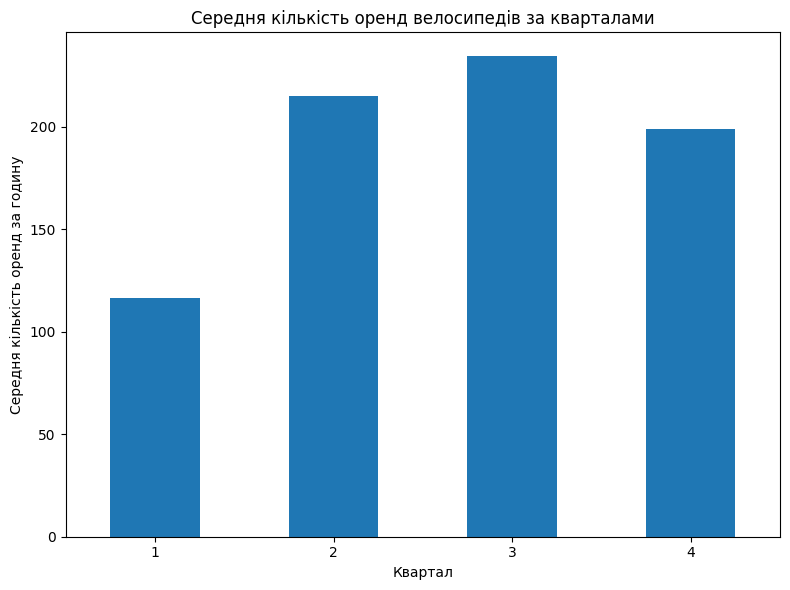

In [22]:
seasonal_avg.plot(
    kind='bar',
    figsize=(8, 6),
    title='Середня кількість оренд велосипедів за кварталами',
    xlabel='Квартал',
    ylabel='Середня кількість оренд за годину'
)
plt.xticks(rotation=0)
plt.tight_layout()

In [23]:
season_map = {
    12: 1, 1: 1, 2: 1,      # Winter
    3: 2, 4: 2, 5: 2,        # Summer
    6: 3, 7: 3, 8: 3, 9: 3,  # Monsoon
    10: 4, 11: 4             # Post-Monsoon
}

df['weather_season_india'] = df['month'].map(season_map)

In [24]:
df[['month', 'weather_season_india']].drop_duplicates().sort_values('month')

,month,weather_season_india
datetime,,
2011-01-01,1,1
2011-02-01,2,1
2011-03-01,3,2
2011-04-01,4,2
2011-05-01,5,2
2011-06-01,6,3
2011-07-01,7,3
2011-08-01,8,3
2011-09-01,9,3


In [25]:
india_seasonal_avg = df.groupby('weather_season_india')['count'].mean()

In [26]:
season_names = {1: 'Winter', 2: 'Summer', 3: 'Monsoon', 4: 'Post-Monsoon'}
india_seasonal_avg.index = india_seasonal_avg.index.map(season_names)

In [27]:
india_seasonal_avg

,count
weather_season_india,
Winter,125.753430
Summer,184.074210
Monsoon,236.322359
Post-Monsoon,210.688255


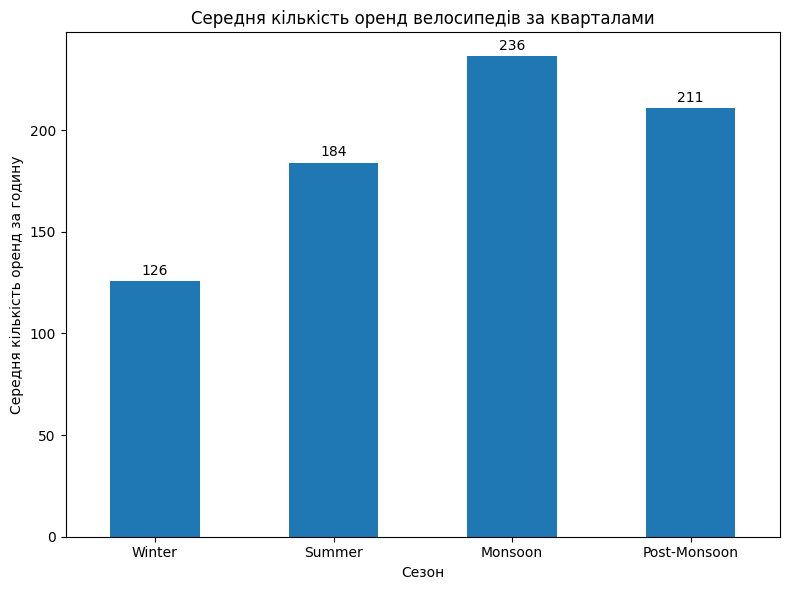

In [31]:
ax = india_seasonal_avg.plot(
    kind='bar',
    figsize=(8, 6),
    title='Середня кількість оренд велосипедів за кварталами',
    xlabel='Сезон',
    ylabel='Середня кількість оренд за годину'
)
for i, value in enumerate(india_seasonal_avg):
    ax.text(i, value + 3, f'{value:.0f}', ha='center')

plt.xticks(rotation=0)
plt.tight_layout()

In [ ]:
Дайте відповіді на питання нижче.

Питання для інтерпретації:

В який квартал найбільша середня кількість оренди велосипедів?
Як ви можете пояснити таку сезонну закономірність?
У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**


**1. В який квартал найбільша середня кількість оренди велосипедів?**

Monsoon

**2. Як ви можете пояснити таку сезонну закономірність?**

Сезон Monsoon (червень-вересень) показує найвищі середні оренди, тому що ці місяці збігаються з найтеплішим періодом року — це вже підтверджено в Завданні 1, де максимум середньомісячних оренд припадав саме на червень-вересень. Тобто назва "Monsoon" тут вводить в оману: попри асоціацію з дощем, ці місяці насправді дають найкомфортнішу для велопрогулянок погоду, і саме тепла погода, а не сезон дощів як такий, пояснює високий попит.

**3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?**

Найпопулярніший сезон (Monsoon, 236 оренд/год) перевищує найменш популярний (Winter, 126 оренд/год) приблизно у 1.87 раза — тобто майже вдвічі.


## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренд велосипедів на годину по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд у цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.



In [32]:
monthly_seasonal = df.groupby('month')['count'].mean()
monthly_seasonal

,count
month,
1,90.366516
2,110.003330
3,148.169811
4,184.160616
5,219.459430
6,242.031798
7,235.325658
8,234.118421
9,233.805281


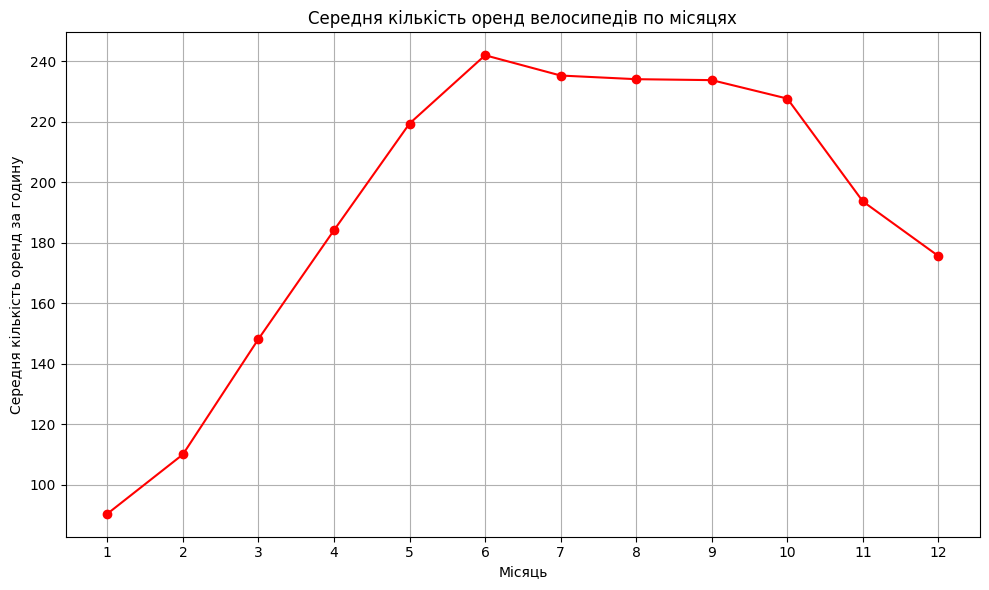

In [33]:
ax = monthly_seasonal.plot(
    kind='line',
    marker='o',
    color='red',
    grid=True,
    figsize=(10, 6),
    title='Середня кількість оренд велосипедів по місяцях',
    xlabel='Місяць',
    ylabel='Середня кількість оренд за годину'
)

plt.xticks(ticks=range(1, 13))
plt.tight_layout()

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
**1. В які місяці спостерігається пік та спад оренди?**

Максимум оренд припадає на червень (близько 242 оренди/год), мінімум — на січень (~90 оренд/год). Після червневого піку лінія поступово знижується (з невеликим плато в липні-вересні), а найрізкіший спад відбувається з жовтня по грудень, після чого досягає найнижчої точки в січні.

**2. Чи збігається ця закономірність з результатами з попереднього завдання?**

Так, закономірність повністю збігається. Сезон Monsoon (червень-вересень) із Завдання 2 включає в себе червень — місяць з найвищим піком оренд на цьому графіку. Аналогічно, сезон Winter (грудень-лютий) включає січень — місяць з найнижчим показником. Це підтверджує, що результати обох завдань узгоджені між собою: агрегація по кварталах (Завдання 2) і по окремих місяцях (Завдання 3) показують ту саму сезонну картину, просто на різному рівні деталізації.

**3. Як може вплинути клімат на оренду велосипедів протягом року?**

Клімат — головний фактор цієї сезонної динаміки, що вже підтверджено в Завданні 1 при накладанні графіків count і temp: крива оренд практично повторює форму кривої температури. Холодна погода взимку (грудень-лютий) знижує комфорт і бажання їздити на велосипеді, тому оренди падають до мінімуму в січні. Навесні, з підвищенням температури, оренди зростають, досягаючи піку влітку (червень), коли погодні умови найбільш комфортні для їзди. Восени, з похолоданням, тенденція повторюється у зворотному напрямку.


## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.


In [34]:
weather_counts = df['weather'].value_counts()
weather_counts

# 1 - ясно
# 2 - туман
# 3 - легкий дощ
# 4 - сильний дощ

,count
weather,
1,7192
2,2834
3,859
4,1


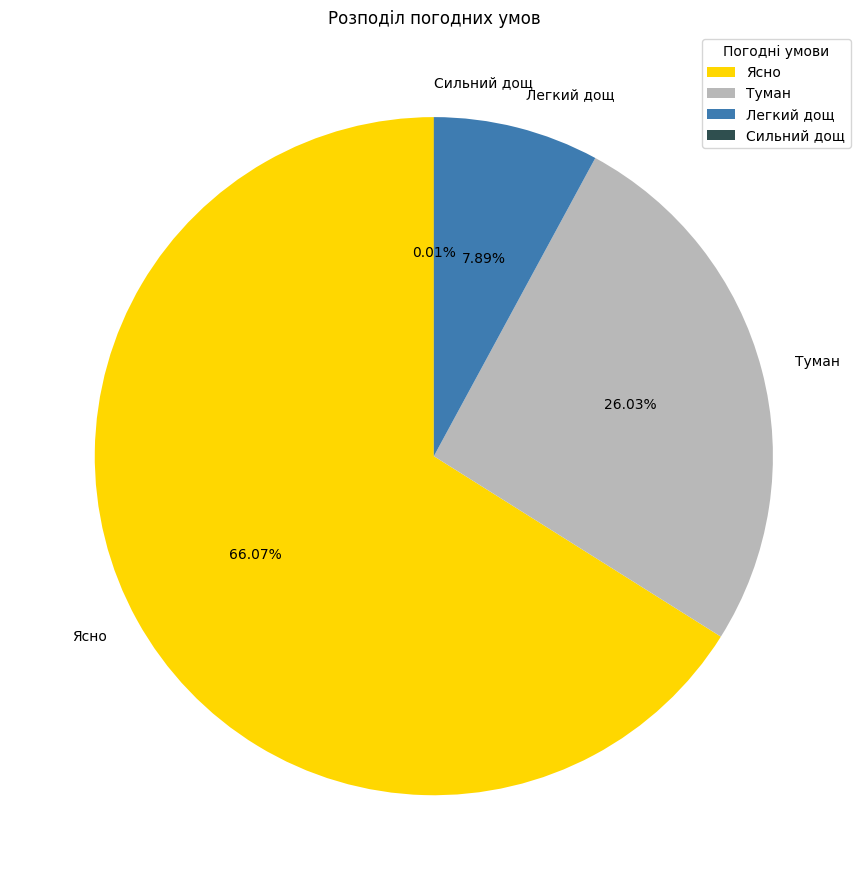

In [58]:
weather_labels = {1: 'Ясно', 2: 'Туман', 3: 'Легкий дощ', 4: 'Сильний дощ'}
labels = [weather_labels[w] for w in weather_counts.index]

colors = ['#FFD700', '#B8B8B8', '#3E7CB1', '#2F4F4F']  # жовтий, сірий, синій, темно-сірий

plt.figure(figsize=(9, 9))
plt.pie(
    weather_counts,
    labels=labels,
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    labeldistance=1.1
 )
plt.title('Розподіл погодних умов')
plt.legend(labels, title='Погодні умови', loc='best')
plt.tight_layout()

In [59]:
weather_rentals = df.groupby('weather')['count'].mean()
weather_rentals

,count
weather,
1,205.236791
2,178.955540
3,118.846333
4,164.000000


In [60]:
df[df['weather'] == 4]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour,weather_season_india
datetime,,,,,,,,,,,,,,,,,,,,
2012-01-09 18:00:00,1,0,1,4,8.2,11.365,86,6.0032,6,158,164,2012-01-09,9,2,0,Monday,2012,1,18,1


Дайте відповіді на питання нижче.

**Питання для інтерпретації:**

**1. Яка погода переважає в датасеті?**

Ясна

**2. Чи є дні із сильним дощем? Яка їх частка?**

Так є, 0,01%

**3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?**

Погодні умови мають чіткий вплив на попит: середня кількість оренд закономірно знижується від ясної погоди (205/год) до туману (179/год) і легкого дощу (119/год) — чим гірша погода, тим менше людей готові орендувати велосипед. Єдиний виняток — сильний дощ (164/год) — статистично ненадійний, оскільки представлений лише однією годиною спостережень (9 січня 2012, 18:00, вечір понеділка). Цей випадок радше показує, що навіть у сильний дощ регулярні користувачі (registered) можуть продовжувати поїздки, вже розпочаті до негоди, тоді як випадкових користувачів (casual) практично немає — тобто погода найбільше відлякує саме спонтанних, а не постійних користувачів сервісу.

Очікуваний результат:

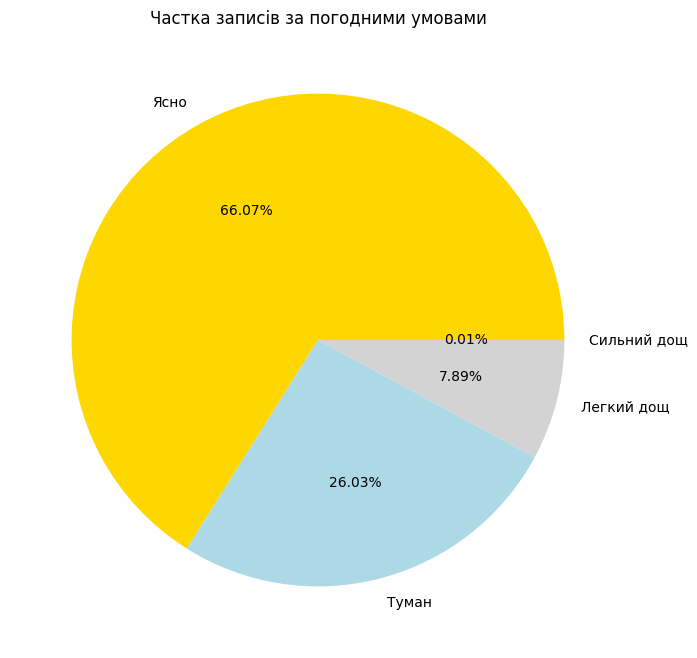

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**

**1. При якій погоді найбільший розкид у кількості оренди?**

Ясна погода (Ясно) — має найширшу коробку і найдовші вуса, тобто найбільшу варіативність кількості оренд.

**2. Чи є викиди (outliers) в даних? При якій погоді?**

Так, викиди присутні у трьох категоріях — Ясно, Туман, Легкий дощ (окрім Сильного дощу, де замало даних для визначення викидів). Найбільш розтягнуті викиди — при легкому дощі, де окремі значення сягають значно вище основної маси даних, аж до ~900 оренд, попри загалом низьку медіану цієї категорії.

**3. При якій погоді медіанне значення оренди найвище?**

Найвища медіана — при ясній погоді (не рахуючи Сильний дощ, де для однієї точки даних медіана технічно дорівнює самому значенню — 164, але це статистично ненадійно через розмір вибірки n=1).


In [61]:
weather_labels = {1: 'Ясно', 2: 'Туман', 3: 'Легкий дощ', 4: 'Сильний дощ'}
df['weather_name'] = df['weather'].map(weather_labels)

In [62]:
df[['weather', 'weather_name']].drop_duplicates()

,weather,weather_name
datetime,,
2011-01-01 00:00:00,1,Ясно
2011-01-01 05:00:00,2,Туман
2011-01-01 18:00:00,3,Легкий дощ
2012-01-09 18:00:00,4,Сильний дощ


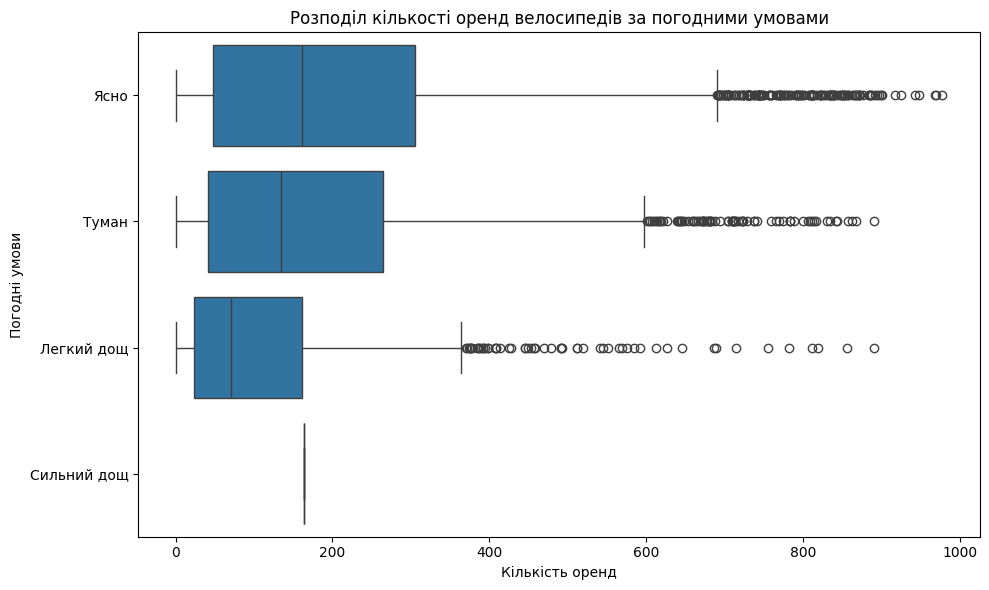

In [63]:
import seaborn as sns

order = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='count',
    y='weather_name',
    order=order
)
plt.title('Розподіл кількості оренд велосипедів за погодними умовами')
plt.xlabel('Кількість оренд')
plt.ylabel('Погодні умови')
plt.tight_layout()

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

Так, зв'язок між температурою та кількістю оренд є, і він нелінійний. У діапазоні від 0°C до приблизно 30°C кількість оренд стабільно зростає з підвищенням температури — чим тепліше, тим більше людей орендують велосипеди. Однак після ~30°C цей ріст сповільнюється, лінія починає коливатись, а після приблизно 32-35°C намічається легкий спад — тобто занадто висока температура (спека) вже трохи знижує комфорт їзди і, відповідно, попит.

Це узгоджується з попередніми висновками (Завдання 1, 3) про зв'язок count і temp, але тут видно додаткову деталь: залежність не безкінечно зростаюча, а має свій оптимум — комфортна тепла погода (приблизно 25-30°C) дає найвищий попит, а екстремальна спека вже трохи його знижує.

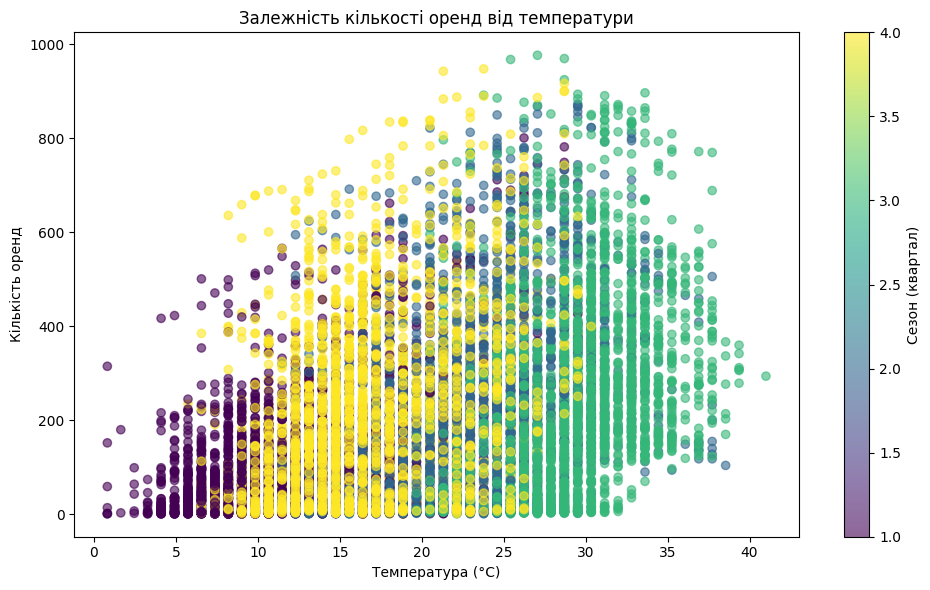

In [69]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['temp'],
    df['count'],
    c=df['season'],
    cmap='viridis',
    alpha=0.6
)
plt.title('Залежність кількості оренд від температури')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість оренд')
plt.colorbar(scatter, label='Сезон (квартал)')
plt.tight_layout()
plt.show()

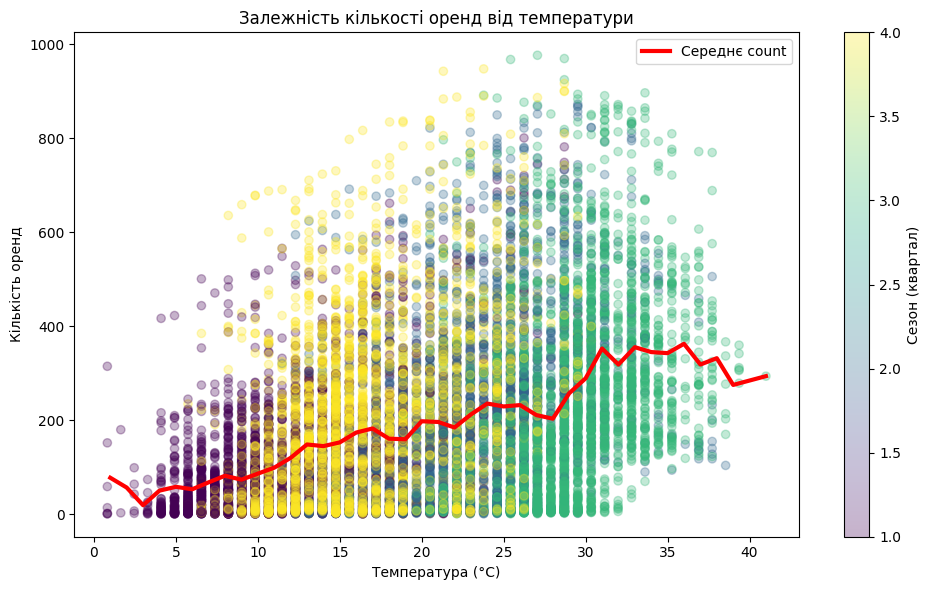

In [71]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['temp'],
    df['count'],
    c=df['season'],
    cmap='viridis',
    alpha=0.3
)

# Групуємо по округленій температурі і рахуємо середнє count
temp_avg = df.groupby(df['temp'].round())['count'].mean()

plt.plot(temp_avg.index, temp_avg.values, color='red', linewidth=3, label='Середнє count')

plt.title('Залежність кількості оренд від температури')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість оренд')
plt.colorbar(scatter, label='Сезон (квартал)')
plt.legend()
plt.tight_layout()

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**

**1. В які дні тижня більше оренд від зареєстрованих користувачів?**

Зареєстровані користувачі стабільно найактивніші в усі будні дні (понеділок-п'ятниця, 160-173 оренди/год), причому різниця між окремими буднями невелика. У вихідні (субота-неділя) їхня активність помітно падає (~124-133 оренди/год).

**2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?**

Це можна пояснити різницею в цілях використання сервісу. Зареєстровані користувачі, найімовірніше, це люди, які регулярно їздять на роботу чи навчання — тому їхня активність висока саме в будні дні і синхронізована з робочим тижнем, а у вихідні, коли їхати нікуди, попит природно спадає.

Випадкові (casual) користувачі демонструють протилежний патерн: різкий сплеск у вихідні (57-64 оренди/год) проти низької активності в будні (23-31 оренди/год). Це узгоджується з гіпотезою, що casual-користувачі — переважно туристи або місцеві мешканці, які беруть велосипед для відпочинку чи прогулянки, а не для регулярних поїздок, тому їхня активність зосереджена саме на вихідних, коли є вільний час для дозвілля.

In [72]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_users = df.groupby('weekday')[['casual', 'registered']].mean()
weekday_users = weekday_users.reindex(weekday_order)
weekday_users

,casual,registered
weekday,,
Monday,29.843972,160.546744
Tuesday,22.979207,166.744639
Wednesday,22.521599,165.889749
Thursday,24.007083,173.289118
Friday,31.001962,166.842381
Saturday,63.625000,133.040404
Sunday,57.051298,123.788474


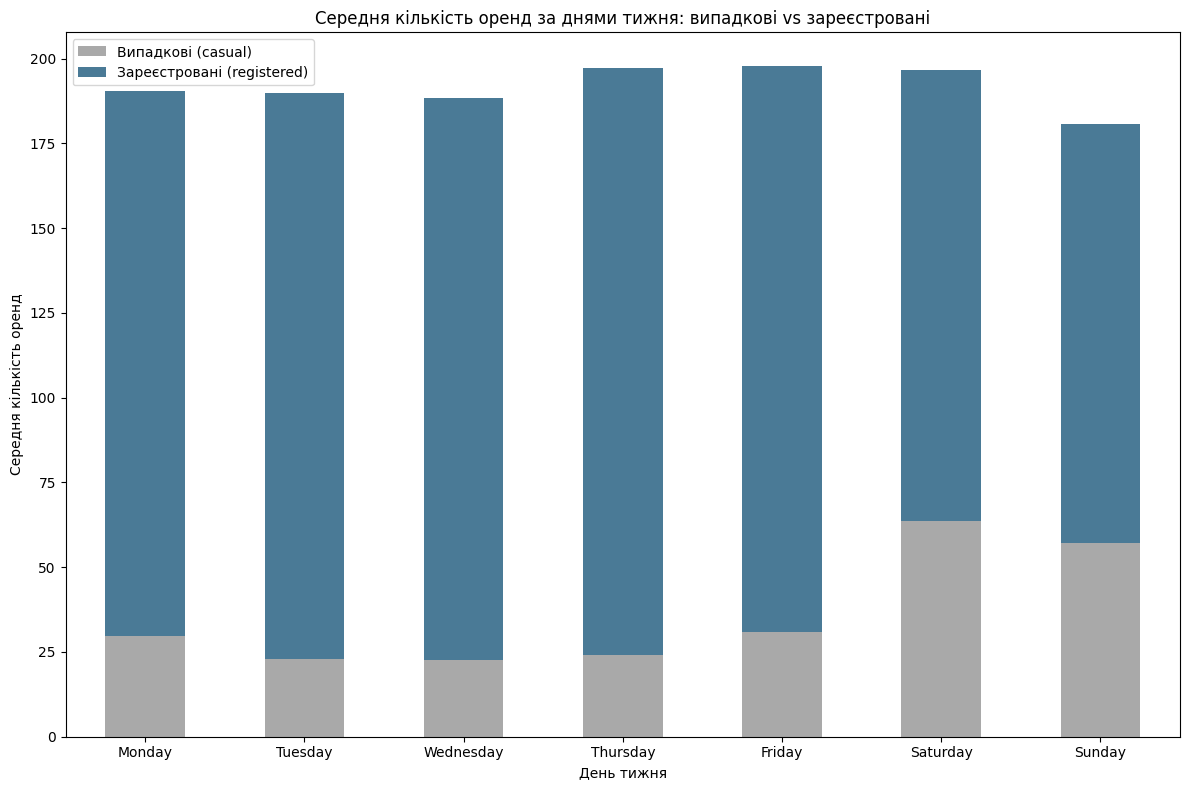

In [80]:
ax = weekday_users.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 8),
    color=['#A9A9A9', '#4A7A96'],  # casual, registered
    title='Середня кількість оренд за днями тижня: випадкові vs зареєстровані',
    xlabel='День тижня',
    ylabel='Середня кількість оренд'
)
plt.xticks(rotation=0)
plt.legend(['Випадкові (casual)', 'Зареєстровані (registered)'], loc='best')
plt.tight_layout()